# Lab 3: Sydney Golden

##1. State the question
What location factors have the greatest influence on increasing salary in USD for data science positions?

##2. Identify the response and relevant predictors
Salary in USD is the response variable, while the relavent predictor variables include remote ratio, company location, and employee residence.

## 3. Related data preparation
In terms of data preparation, we'll need to create a train and test split of the categorical variables. Since all of our response variables are categorical, we will need to apply One Hot Encoding.

In [21]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.inspection import PartialDependenceDisplay
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree, DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer
from sklearn.model_selection import train_test_split, GridSearchCV


In [22]:
df = pd.read_csv('ds_salaries_clean.csv')

In [23]:
df.head()

,ID,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,1,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
1,2,2020,MI,FT,Business Data Analyst,95000,USD,95000,US,0,US,M
2,3,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3,4,2020,EN,FT,Data Analyst,20000,EUR,22809,PT,100,PT,M
4,5,2020,EN,FT,Data Scientist,43200,EUR,49268,DE,0,DE,S


In [24]:
# One-hot encode categorical variables
encoder = OneHotEncoder(handle_unknown='ignore')
categorical_cols = ['remote_ratio', 'company_location', 'employee_residence']
encoded_col = pd.DataFrame(encoder.fit_transform(df[categorical_cols]).toarray())
encoded_col.columns = encoder.get_feature_names_out(categorical_cols)

In [25]:
# Split the Data between test and train
X_train, X_test, y_train, y_test =  train_test_split(encoded_col,
                                                 df['salary_in_usd'],
                                                 train_size = 2000, test_size = 1191, # 3191 values in df
                                                 random_state = 1)

#4. Previous Models: Updated to use classifiers instead of regressor methods

In [34]:
# Bin the target variable into salary categories
y_train_binned = pd.cut(y_train, bins=[0, 50000, 100000, 200000, 1000000],
                         labels=['low', 'medium', 'high', 'very_high'],
                         include_lowest=True)
y_test_binned = pd.cut(y_test, bins=[0, 50000, 100000, 200000, 1000000],
                        labels=['low', 'medium', 'high', 'very_high'],
                        include_lowest=True)

# Check for any remaining NaN values
print("NaN in y_train_binned:", y_train_binned.isna().sum())
print("NaN in y_test_binned:", y_test_binned.isna().sum())

NaN in y_train_binned: 0
NaN in y_test_binned: 0


Bagging Model

In [35]:
# fit Bagging model
df_bagging = RandomForestClassifier(max_features=X_train.shape[1],
                                    random_state=1,
                                    n_estimators=25,
                                    n_jobs=-1)
df_bagging.fit(X_train, y_train_binned)

print("\n=== Bagging Model ===")
print("Number of trees:", df_bagging.n_estimators)
print("Number of features tried at each split:", df_bagging.max_features)
print("Training accuracy: {:.2f}%".format(df_bagging.score(X_train, y_train_binned) * 100))
print("Test accuracy: {:.2f}%".format(df_bagging.score(X_test, y_test_binned) * 100))


=== Bagging Model ===
Number of trees: 25
Number of features tried at each split: 153
Training accuracy: 65.50%
Test accuracy: 62.80%


Random Forest Model

In [36]:
# fit Random Forests model
df_rf = RandomForestClassifier(max_features=3, random_state=1, n_jobs=-1)
df_rf.fit(X_train, y_train_binned)

print("\n=== Random Forest Model ===")
print("Number of trees:", df_rf.n_estimators)
print("Number of features tried at each split:", df_rf.max_features)
print("Training accuracy: {:.2f}%".format(df_rf.score(X_train, y_train_binned) * 100))
print("Test accuracy: {:.2f}%".format(df_rf.score(X_test, y_test_binned) * 100))


=== Random Forest Model ===
Number of trees: 100
Number of features tried at each split: 3
Training accuracy: 65.50%
Test accuracy: 62.64%


Gradient Boosting

In [38]:
# fit Gradient Boosting model
boost_df = GradientBoostingClassifier(n_estimators=100, max_depth=4, random_state=1)
boost_df.fit(X_train, y_train_binned)

print("Number of trees:", boost_df.n_estimators)
print("Number of features tried at each split:", boost_df.max_features)
print("Training accuracy: {:.2f}%".format(boost_df.score(X_train, y_train_binned) * 100))
print("Test accuracy: {:.2f}%".format(boost_df.score(X_test, y_test_binned) * 100))

Number of trees: 100
Number of features tried at each split: None
Training accuracy: 65.10%
Test accuracy: 62.64%


Cat Boosting

In [41]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score

# Initialize and train CatBoost Classifier
model_catboost = CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1, random_seed=1, verbose=False)
model_catboost.fit(X_train, y_train_binned)

# Predict on test set
y_pred_catboost = model_catboost.predict(X_test)

print("Training accuracy: {:.2f}%".format(model_catboost.score(X_train, y_train_binned) * 100))
print("Test accuracy: {:.2f}%".format(accuracy_score(y_test_binned, y_pred_catboost) * 100))

Training accuracy: 62.50%
Test accuracy: 61.13%


After binning the y training variables into different ranks of pay, training and testing accuracy increased to above 60% for all models. The bagging model had the highest test accuracy at 62.80%

#5. Apply Support Vector Classification Model

In [44]:
import numpy as np
from matplotlib.pyplot import subplots, cm
import sklearn.model_selection as skm
from ISLP import load_data, confusion_table

In [45]:
from sklearn.svm import SVC
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay


In [46]:
# Create the support vector machine
svm_linear = SVC(C=10, kernel='linear')
svm_linear.fit(X_train, y_train_binned)


SVC(C=10, kernel='linear')

In [51]:
print(X_train.columns.tolist())

['remote_ratio_0', 'remote_ratio_50', 'remote_ratio_100', 'company_location_AE', 'company_location_AL', 'company_location_AM', 'company_location_AR', 'company_location_AS', 'company_location_AT', 'company_location_AU', 'company_location_BA', 'company_location_BE', 'company_location_BO', 'company_location_BR', 'company_location_BS', 'company_location_CA', 'company_location_CF', 'company_location_CH', 'company_location_CL', 'company_location_CN', 'company_location_CO', 'company_location_CR', 'company_location_CZ', 'company_location_DE', 'company_location_DK', 'company_location_DZ', 'company_location_EE', 'company_location_EG', 'company_location_ES', 'company_location_FI', 'company_location_FR', 'company_location_GB', 'company_location_GH', 'company_location_GR', 'company_location_HK', 'company_location_HN', 'company_location_HR', 'company_location_HU', 'company_location_ID', 'company_location_IE', 'company_location_IL', 'company_location_IN', 'company_location_IQ', 'company_location_IR',

There are 153 features. Most of these features include different company locations or employee residencies.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


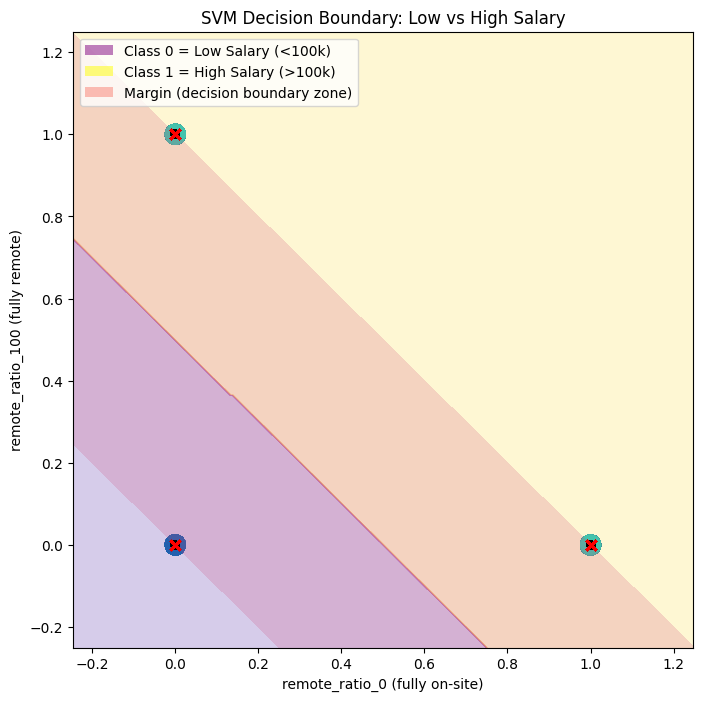

In [57]:
# More data prep
# Select two specific features  to meet binary requirements of SVM and reset index
X_train_2d = X_train[['remote_ratio_0', 'remote_ratio_100']].reset_index(drop=True)
y_train_binary_reset = y_train_binary.reset_index(drop=True)

# Train SVM on 2 features
svm_linear = SVC(C=0.1, kernel='linear')
svm_linear.fit(X_train_2d, y_train_binary_reset)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
plot_svm(X_train_2d, y_train_binary_reset, svm_linear, ax=ax)

# Add legend and labels
ax.set_xlabel("remote_ratio_0 (fully on-site)")
ax.set_ylabel("remote_ratio_100 (fully remote)")
ax.set_title("SVM Decision Boundary: Low vs High Salary")

# Add custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='purple', alpha=0.5, label='Class 0 = Low Salary (<100k)'),
    Patch(facecolor='yellow', alpha=0.5, label='Class 1 = High Salary (>100k)'),
    Patch(facecolor='salmon', alpha=0.5, label='Margin (decision boundary zone)')
]
ax.legend(handles=legend_elements, loc='upper left')
plt.show()

The point at (1,0) shows a worker that is fully on site and the point (0,1) shows a worker that is fully remote. Both are on the margin and count as support vectors, but give conflicting information on whether remote or on-site workers have a high salary. This means that the two features likely do not have a strong influence on the response variable salary, since the decision boundary is unclear.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


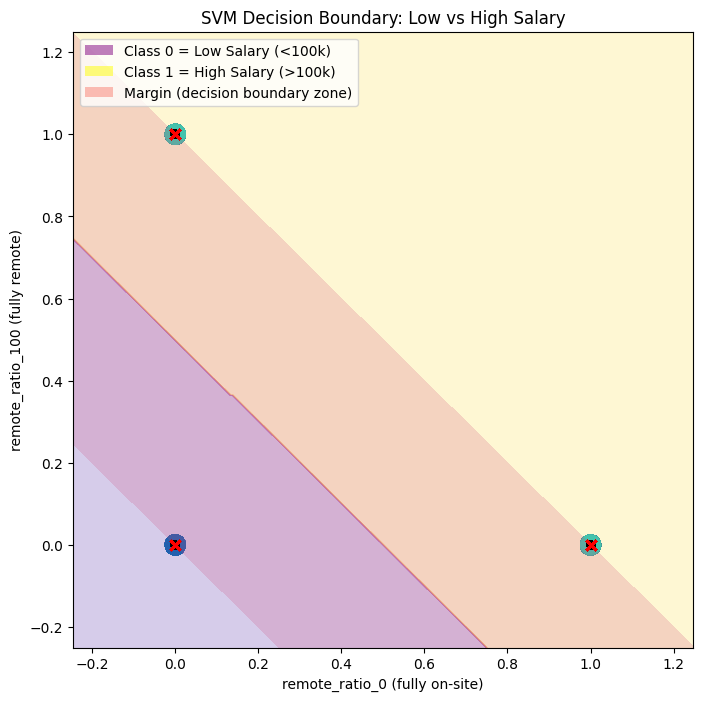

In [55]:
# Smaller value of salary parameter
# Select two specific features  to meet binary requirements of SVM and reset index
X_train_2d = X_train[['remote_ratio_0', 'remote_ratio_100']].reset_index(drop=True)
y_train_binary_reset = y_train_binary.reset_index(drop=True)

# Train SVM on 2 features
svm_linear_small = SVC(C=0.1, kernel='linear')
svm_linear_small.fit(X_train_2d, y_train_binary_reset)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
plot_svm(X_train_2d, y_train_binary_reset, svm_linear_small, ax=ax)

# Add legend and labels
ax.set_xlabel("remote_ratio_0 (fully on-site)")
ax.set_ylabel("remote_ratio_100 (fully remote)")
ax.set_title("SVM Decision Boundary: Low vs High Salary")

# Add custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='purple', alpha=0.5, label='Class 0 = Low Salary (<100k)'),
    Patch(facecolor='yellow', alpha=0.5, label='Class 1 = High Salary (>100k)'),
    Patch(facecolor='salmon', alpha=0.5, label='Margin (decision boundary zone)')
]
ax.legend(handles=legend_elements, loc='upper left')
plt.show()

Having a smaller salary parameter does not change the plot.

# 6. Tuning

In [60]:
kfold = skm.KFold(5,
                  random_state=0,
                  shuffle=True)
grid = skm.GridSearchCV(svm_linear,
                        {'C':[0.001,0.01,0.1,1,5,10,100]},
                        refit=True,
                        cv=kfold,
                        scoring='accuracy')
grid.fit(X_train, y_train_binned)
print(grid.best_params_)

{'C': 100}


Grid.best.params tells us that a C value of 100 will give us our highest test score.

# 7. Cross Validation

In [61]:
grid.cv_results_[('mean_test_score')]

array([0.503 , 0.569 , 0.5995, 0.6075, 0.607 , 0.6075, 0.6085])

Upon cross validation, C = 100 gave the best mean test score at 60.85%.

#8. Adjusting the SVM model based on CV results

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


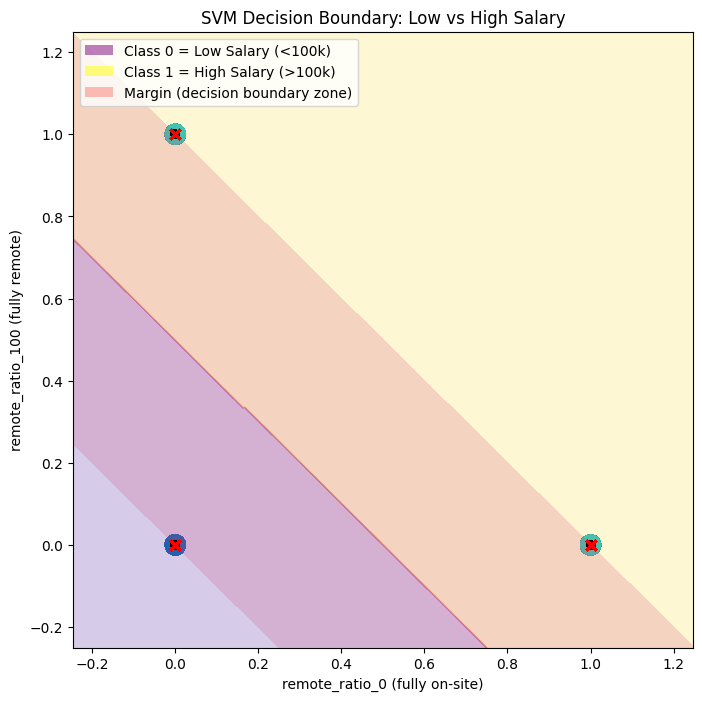

In [62]:
# More data prep
# Select two specific features  to meet binary requirements of SVM and reset index
X_train_2d = X_train[['remote_ratio_0', 'remote_ratio_100']].reset_index(drop=True)
y_train_binary_reset = y_train_binary.reset_index(drop=True)

# Train SVM on 2 features
svm_linear = SVC(C=100, kernel='linear') # Using C = 100
svm_linear.fit(X_train_2d, y_train_binary_reset)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
plot_svm(X_train_2d, y_train_binary_reset, svm_linear, ax=ax)

# Add legend and labels
ax.set_xlabel("remote_ratio_0 (fully on-site)")
ax.set_ylabel("remote_ratio_100 (fully remote)")
ax.set_title("SVM Decision Boundary: Low vs High Salary")

# Add custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='purple', alpha=0.5, label='Class 0 = Low Salary (<100k)'),
    Patch(facecolor='yellow', alpha=0.5, label='Class 1 = High Salary (>100k)'),
    Patch(facecolor='salmon', alpha=0.5, label='Margin (decision boundary zone)')
]
ax.legend(handles=legend_elements, loc='upper left')
plt.show()

Since there are only three support vectors, changing C to 100 did not make any noticable changes to the plot.

# 9. Reintroduction to the PCA method

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


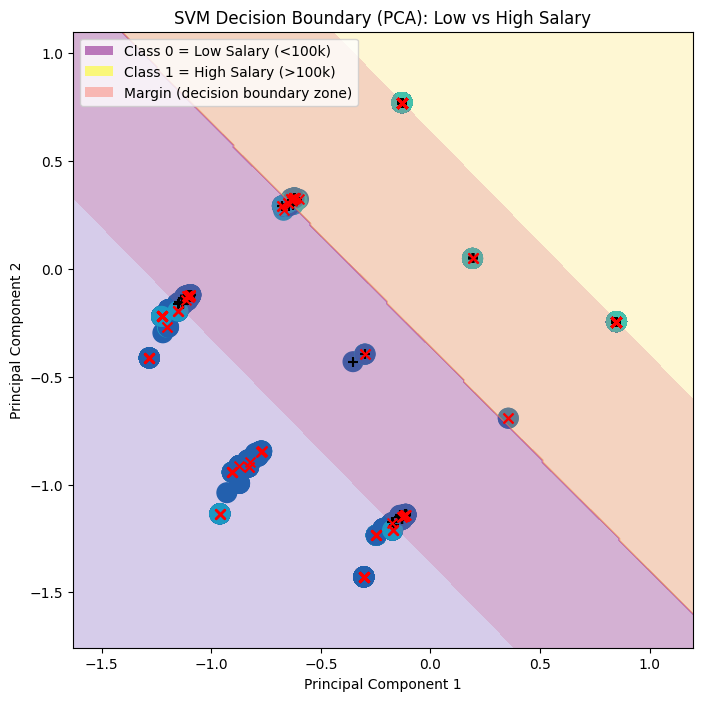

Variance explained by PC1 and PC2: 59.17%


In [63]:
from sklearn.decomposition import PCA

# Reduce to 2D using PCA
pca = PCA(n_components=2)
X_train_2d = pd.DataFrame(pca.fit_transform(X_train), columns=['PC1', 'PC2'])
X_test_2d = pd.DataFrame(pca.transform(X_test), columns=['PC1', 'PC2'])
y_train_binary_reset = y_train_binary.reset_index(drop=True)

# Train SVM on 2D PCA data
svm_linear = SVC(C=100, kernel='linear')
svm_linear.fit(X_train_2d, y_train_binary_reset)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
plot_svm(X_train_2d, y_train_binary_reset, svm_linear, ax=ax)

# Add legend and labels
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("SVM Decision Boundary (PCA): Low vs High Salary")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='purple', alpha=0.5, label='Class 0 = Low Salary (<100k)'),
    Patch(facecolor='yellow', alpha=0.5, label='Class 1 = High Salary (>100k)'),
    Patch(facecolor='salmon', alpha=0.5, label='Margin (decision boundary zone)')
]
ax.legend(handles=legend_elements, loc='upper left')
plt.show()

# Check how much variance is explained
print("Variance explained by PC1 and PC2: {:.2f}%".format(
    sum(pca.explained_variance_ratio_) * 100))

PCA (Principal Component Analysis) was utilized to reduce the dimensions of the 153 features while still attempting to preserve variance. In this model, the decision boundary moved up on the plot but the margin still remains large. Most misclassified values were from lower salaries, which are clustered in the purple region.

#10. Check and analyze the model performance

In [64]:
# SVM Linear (original - full features)
svm_linear_full = SVC(C=10, kernel='linear')
svm_linear_full.fit(X_train, y_train_binned)

# SVM Linear Small (C=0.1, 2 binary features)
X_train_2feat = X_train[['remote_ratio_0', 'remote_ratio_100']].reset_index(drop=True)
X_test_2feat = X_test[['remote_ratio_0', 'remote_ratio_100']].reset_index(drop=True)
y_train_bin_reset = y_train_binary.reset_index(drop=True)
y_test_bin_reset = y_test_binary.reset_index(drop=True)

svm_linear_small = SVC(C=0.1, kernel='linear')
svm_linear_small.fit(X_train_2feat, y_train_bin_reset)

# SVM Linear C=100 (2 binary features)
svm_linear_c100 = SVC(C=100, kernel='linear')
svm_linear_c100.fit(X_train_2feat, y_train_bin_reset)

# SVM Linear PCA (2 PCA components)
svm_linear_pca = SVC(C=100, kernel='linear')
svm_linear_pca.fit(X_train_2d, y_train_binary_reset)

# Print results
print("=== SVM Linear (Full Features, C=10) ===")
print("Training accuracy: {:.2f}%".format(svm_linear_full.score(X_train, y_train_binned) * 100))
print("Test accuracy: {:.2f}%".format(svm_linear_full.score(X_test, y_test_binned) * 100))

print("\n=== SVM Linear Small (2 Features, C=0.1) ===")
print("Training accuracy: {:.2f}%".format(svm_linear_small.score(X_train_2feat, y_train_bin_reset) * 100))
print("Test accuracy: {:.2f}%".format(svm_linear_small.score(X_test_2feat, y_test_bin_reset) * 100))

print("\n=== SVM Linear (2 Features, C=100) ===")
print("Training accuracy: {:.2f}%".format(svm_linear_c100.score(X_train_2feat, y_train_bin_reset) * 100))
print("Test accuracy: {:.2f}%".format(svm_linear_c100.score(X_test_2feat, y_test_bin_reset) * 100))

print("\n=== SVM Linear PCA (2 Components, C=100) ===")
X_test_2d_pca = pd.DataFrame(pca.transform(X_test), columns=['PC1', 'PC2'])
print("Training accuracy: {:.2f}%".format(svm_linear_pca.score(X_train_2d, y_train_binary_reset) * 100))
print("Test accuracy: {:.2f}%".format(svm_linear_pca.score(X_test_2d_pca, y_test_binary.reset_index(drop=True)) * 100))

=== SVM Linear (Full Features, C=10) ===
Training accuracy: 64.55%
Test accuracy: 62.97%

=== SVM Linear Small (2 Features, C=0.1) ===
Training accuracy: 67.15%
Test accuracy: 69.61%

=== SVM Linear (2 Features, C=100) ===
Training accuracy: 67.15%
Test accuracy: 69.61%

=== SVM Linear PCA (2 Components, C=100) ===
Training accuracy: 79.35%
Test accuracy: 80.27%


The best model came from the PCA model with two PCA components at a test score of 80.27%. This is likely because of the PCA's ability to reduce dimensions to the most important features, as opposed to the other models only considering two features in the analysis or observing all features instead of the most valuable ones. The SVM models with only two features had an improved performance compared to the one that considered all of the features, but their training and test accuracy scores were about the same despite adjusting C.

# 11. Explain how this compares with tree-based methods

The SVM models with two features were able to produce slightly higher training and testing accuracies than the tree-based methods by about 7%. This improved performance was likely due to simplifying the classes into a binary of two classes (low and high) instead of four (low, medium, high, and very high), allowing the SVM models to create clearer boundaries.